# Switching Mechanism

**RQ1 placement, RQ2 handover, on a reference that is exact.**

A two-mode integrator with a known analytical solution. Each mode integrates the
same scalar state with a different gain, so the state format is identical on both
sides and `_adapt_state` is the identity. That isolates the four things the
mechanism has to get right — mode selection, state transfer, active-model
delegation, and the typed `switch_events` history — from any model discrepancy.

Because the reference is analytic, the residual here is the localization
tolerance and nothing else. The case-study notebooks measure the same quantities
where the reference is itself numerical.

In [6]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().resolve()))
from evidence import repo_root

REPO = repo_root()

from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)

plt = set_professional_style(latex=True)
print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


## Model and scenario

A generated region boundary switches from mode A to mode B when the state reaches
`X_SWITCH`. The hybrid algorithm localizes that crossing by bisection; the
analytical solution is piecewise linear with slope `K_A` before it and `K_B`
after.

In [7]:
from syssimx.core.base import CoSimComponent
from syssimx.core.multi_comp import ModeKey, MultiComponent
from syssimx.core.port import PortSpec, PortType
from syssimx.system.algorithms.hybrid import HybridAlgorithm
from syssimx.system.system import System

K_A, K_B = 1.0, 2.0
# Chosen so the crossing is NOT a multiple of the macro step: with
# K_A = 1 the switch is due at t = X_SWITCH, and 0.53 / 0.05 = 10.6.
# An earlier revision used 0.5, which is exactly 10 macro steps, so a
# grid-snapping policy would have scored a placement error of zero and
# the figure demonstrated nothing about localization.
X_SWITCH = 0.53
T0, T_END, MACRO_DT = 0.0, 1.0, 0.05
SWITCH_BAND = 1e-6
TOL_TIME = 1e-10

FIGURE_ID = "V1_mechanism"
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)


class GainIntegrator(CoSimComponent):
    '''Scalar integrator with gain-dependent autonomous dynamics.'''

    def __init__(self, name: str, gain: float):
        super().__init__(name, label=name)
        self.gain = float(gain)
        self.x = 0.0
        self.output_specs = {"x": PortSpec(name="x", type=PortType.REAL, direction="out")}

    def _initialize_component(self, t0): self.x = 0.0
    def _do_step_internal(self, t, dt): self.x += self.gain * dt
    def _update_output_states(self, t=None, event_names=None): self.outputs["x"].set(self.x, t=t)
    def get_state(self): return {"x": self.x}
    def snapshot_state(self): return {"x": self.x}
    def restore_state(self, snapshot, t): self.x = float(snapshot["x"])

    def set_state(self, state, t):
        self.x = float(state["x"])
        self.t = t
        if "x" in self.outputs:
            self._update_output_states(t)


class SwitchingGain(MultiComponent):
    '''Two gains behind one interface. Both modes share the state format.'''

    def __init__(self, name="SwitchingGain", initial_mode: ModeKey = "A"):
        super().__init__(
            name=name,
            models={"A": GainIntegrator(f"{name}_A", K_A), "B": GainIntegrator(f"{name}_B", K_B)},
            initial_mode=initial_mode,
        )
        self._unify_ports()

    def _adapt_state(self, state, target_mode):
        return {"x": float(state["x"])}


def analytical_x(t):
    t = np.asarray(t, dtype=float)
    t_switch = X_SWITCH / K_A
    return np.where(t <= t_switch, K_A * t, X_SWITCH + K_B * (t - t_switch))

## Run

In [8]:
plant = SwitchingGain()
plant.record_switch_state = True
plant.set_switch_regions(
    key=lambda comp: float(comp.outputs["x"].get()),
    breakpoints=(X_SWITCH - SWITCH_BAND,),
    modes=("A", "B"),
    band=SWITCH_BAND,
)

system = System(name="SwitchingGainVerification")
system.add_component(plant)
system.algorithm = HybridAlgorithm()
system.initialize(T0)
system.algorithm.tol_time = TOL_TIME
system.run(t0=T0, tf=T_END, dt=MACRO_DT)

times, history = system.get_history()[plant.name]
times = np.asarray(times, dtype=float)
x_num = np.asarray(history["x"], dtype=float)

event = plant.switch_events[0]
t_switch_exact = X_SWITCH / K_A
max_abs_error = float(np.max(np.abs(x_num - analytical_x(times))))
placement_error = abs(float(event.time) - t_switch_exact)
# What a policy that switched on the next communication point would
# have scored on the same crossing. Computed, not measured: the
# grid-snapping selector was removed in c306370.
grid_counterfactual = (
    np.ceil(t_switch_exact / MACRO_DT) * MACRO_DT - t_switch_exact
)
transfer_error = abs(float(event.target_state["x"]) - float(event.source_state["x"]))

display(pd.Series({
    "switches dispatched": len(plant.switch_events),
    "transition": f"{event.from_mode} -> {event.to_mode}",
    "switch time (s)": f"{event.time:.12f}",
    "analytic switch time (s)": f"{t_switch_exact:.12f}",
    "placement error (s)": f"{placement_error:.2e}",
    "grid-snap counterfactual (s)": f"{grid_counterfactual:.2e}",
    "improvement factor": f"{grid_counterfactual / placement_error:.1e}",
    "state discontinuity at transfer": f"{transfer_error:.2e}",
    "max |x - x_exact|": f"{max_abs_error:.2e}",
}).to_frame("value"))

assert len(plant.switch_events) == 1, plant.switch_events
assert (event.from_mode, event.to_mode) == ("A", "B")
assert transfer_error == 0.0, "the handover introduced a discontinuity"
# Off-grid, the state residual is set by the hysteresis band, not by
# tol_time: the boundary arms at breakpoint + band, so a sub-band offset
# delta in the switch instant leaves a state error of delta * (K_B - K_A).
# The earlier 1e-8 bound only held because the crossing coincided with a
# communication point, which is exactly what made the figure vacuous.
assert max_abs_error < 10 * SWITCH_BAND, (
    f'state error {max_abs_error:.2e} exceeds ten times the band {SWITCH_BAND:.0e}'
)
assert placement_error < 0.01 * MACRO_DT, "the switch landed near a communication point"
assert grid_counterfactual > 0.1 * MACRO_DT, (
    f"the analytic crossing sits {grid_counterfactual:.2e} s from the next "
    f"communication point, too close for the counterfactual to mean anything. "
    f"Choose an X_SWITCH whose crossing is not near a multiple of MACRO_DT."
)
print("OK: one localized switch, exact state handover, analytic agreement.")

,value
switches dispatched,1
transition,A -> B
switch time (s),0.530000305176
analytic switch time (s),0.530000000000
placement error (s),3.05e-07
grid-snap counterfactual (s),2.00e-02
improvement factor,6.6e+04
state discontinuity at transfer,0.00e+00
max |x - x_exact|,3.05e-07


OK: one localized switch, exact state handover, analytic agreement.


In [9]:
record(
    FIGURE_ID,
    {
        "placement_error_s": placement_error,
        "grid_counterfactual_s": grid_counterfactual,
        "switch_time_s": float(event.time),
        "analytic_switch_time_s": t_switch_exact,
        "state_discontinuity": transfer_error,
        "max_abs_state_error": max_abs_error,
        "n_switches": len(plant.switch_events),
        "macro_dt": MACRO_DT,
        "tol_time": TOL_TIME,
        "band": SWITCH_BAND,
    },
    directory=RESULTS,
    notebook="01_mechanism",
    smoke=False,
)

WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/V1_mechanism.json')

## Figure

One panel: the numerical trajectory against the analytic solution, with the
active mode shaded and the localized switch marked. The switch does not sit on a
communication point.

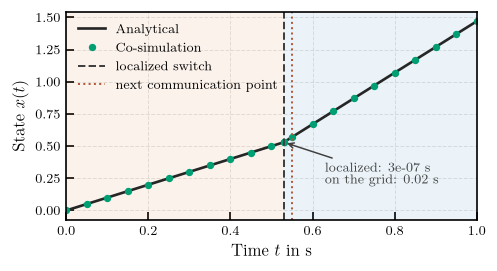

In [10]:
t_dense = np.linspace(T0, T_END, 400)
t_switch = float(event.time)
next_grid_point = np.ceil(t_switch / MACRO_DT) * MACRO_DT

fig, ax = plt.subplots(figsize=(0.72 * FULL_WIDTH, 0.40 * FULL_WIDTH))

ax.axvspan(T0, t_switch, color="#D55E00", alpha=0.08, linewidth=0)
ax.axvspan(t_switch, T_END, color="#0072B2", alpha=0.08, linewidth=0)

ax.plot(t_dense, analytical_x(t_dense), color="0.15", linewidth=1.6, label="Analytical")
ax.plot(times, x_num, color="#009E73", linestyle="none", marker="o",
        markersize=3.5, label="Co-simulation")

ax.axvline(t_switch, color="0.25", linestyle="--", linewidth=1.2,
           label="localized switch")
ax.axvline(next_grid_point, color="#B65A3C", linestyle=":", linewidth=1.2,
           label="next communication point")

annotation = (
    "localized: {:.0e} s".format(placement_error)
    + "\n"
    + "on the grid: {:.2f} s".format(grid_counterfactual)
)
ax.annotate(
    annotation,
    xy=(t_switch, X_SWITCH),
    xytext=(t_switch + 0.10, X_SWITCH - 0.32),
    arrowprops=dict(arrowstyle="->", color="0.25", lw=0.9),
    fontsize=8, color="0.25",
)

ax.set_xlim(T0, T_END)
ax.set_xlabel(r"Time $t$ in s")
ax.set_ylabel(r"State $x(t)$")
ax.grid(True, alpha=0.4)
ax.legend(loc="upper left", frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(OUT_DIR / f"{FIGURE_ID}.pdf", bbox_inches="tight")
plt.show()


## Reading the result

The placement error is the bisection tolerance, not a property of the macro grid:
the switch lands between communication points. The state discontinuity is exactly
zero because both modes share one state format, which is the floor the
case-study handover is measured against — there, `_adapt_state` maps between
different representations and the residual is no longer zero by construction.

The hysteresis band and the multi-boundary cases are covered by
`tests/unit/core/test_multi_comp.py` and `tests/integration/test_multi_comp_switching.py`
rather than repeated here.